# 01 — EDA: cart sessions

**QuickBasket**, a 10-minute grocery service. A ₹499 free-delivery threshold already
exists for everyone. The experiment adds a progress nudge on the cart page:

| Arm | Cart page |
| --- | --- |
| `control` | flat ₹35 delivery fee, no nudge |
| `treatment` | *"Add ₹120 more to unlock FREE delivery"* |

One cart session per user, randomised 50/50, four weeks (2 Feb – 1 Mar 2026).

This notebook does one job: decide whether the randomisation can be trusted, and
establish the binary outcome that notebook 03 will test. No hypothesis testing here.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"  # Arial has no rupee glyph

raw = pd.read_csv(Path("../data/qb_cart_sessions.csv"), parse_dates=["session_ts"])
raw.shape

(161920, 10)

In [2]:
raw.head()

,session_id,user_id,group,session_ts,city_tier,device,is_new_user,cart_items,cart_subtotal_inr,order_placed
0,S0098829,U094557,treatment,2026-02-02 00:02:11,tier_2,android,0,9,672.8900,0
1,S0003211,U007043,control,2026-02-02 00:02:52,metro,android,0,3,305.9500,1
2,S0155253,U073222,control,2026-02-02 00:06:32,tier_3,android,0,5,231.9300,1
3,S0114016,U103578,control,2026-02-02 00:12:45,metro,android,0,1,90.9400,1
4,S0066057,U115851,treatment,2026-02-02 00:13:22,tier_3,android,1,2,153.3100,0


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161920 entries, 0 to 161919
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   session_id         161920 non-null  object        
 1   user_id            161920 non-null  object        
 2   group              161920 non-null  object        
 3   session_ts         161920 non-null  datetime64[ns]
 4   city_tier          161920 non-null  object        
 5   device             161920 non-null  object        
 6   is_new_user        161920 non-null  int64         
 7   cart_items         161920 non-null  int64         
 8   cart_subtotal_inr  161920 non-null  float64       
 9   order_placed       161920 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 12.4+ MB


## 1. Data quality

Three things to check before anything else: duplicates, missing values, and whether the
categorical columns actually contain the categories we think they do.

In [4]:
print("missing values per column")
print(raw.isna().sum())
print(f"\nrows                {len(raw):,}")
print(f"unique session_id   {raw['session_id'].nunique():,}")
print(f"unique user_id      {raw['user_id'].nunique():,}")
print(f"\ndevice values: {raw['device'].unique().tolist()}")

missing values per column
session_id           0
user_id              0
group                0
session_ts           0
city_tier            0
device               0
is_new_user          0
cart_items           0
cart_subtotal_inr    0
order_placed         0
dtype: int64

rows                161,920
unique session_id   160,000
unique user_id      160,000

device values: ['android', 'Android', 'ios', 'web']


Two defects, both of them common in real event data:

1. **`session_id` is not unique.** The analytics SDK double-fired on a slice of traffic,
   so ~1.2% of sessions were logged twice. Left in, those sessions get counted twice in
   the conversion denominator *and* numerator — harmless to the rate, but it inflates
   the sample size, which shrinks the standard error and makes every p-value look
   better than it is. Drop them.
2. **`device` has both `android` and `Android`.** One SDK version reported the label
   capitalised. Any group-by on `device` currently splits Android in two.

`user_id` is unique once the duplicates are gone — one session per user is the design,
and it is what makes every observation independent.

In [5]:
df = raw.drop_duplicates(subset="session_id").copy()
df["device"] = df["device"].str.lower()

print(f"dropped {len(raw) - len(df):,} duplicate rows -> {len(df):,} sessions")
assert df["session_id"].is_unique and df["user_id"].is_unique
df["device"].value_counts()

dropped 1,920 duplicate rows -> 160,000 sessions


device
android    99217
ios        36899
web        23884
Name: count, dtype: int64

## 2. Randomisation health — the sample ratio mismatch (SRM) check

Before reading any result, check the split is what it claims to be. The allocation is
meant to be 50/50, so under a working randomiser the arm counts follow a binomial around
n/2. A chi-square goodness-of-fit test with 1 degree of freedom asks how surprising the
observed split is.

The convention is a strict threshold — **p < 0.001** — because SRM is a bug signal, not
a business effect, and you do not want to chase noise. But when it does fire, it usually
means users are being *filtered* differently between arms, and a filtered arm is no
longer a random arm.

In [6]:
# chisquare with no expected frequencies assumes a uniform split -- exactly the 50/50 null.
counts = df["group"].value_counts()
chi2, p = stats.chisquare([counts["control"], counts["treatment"]])
print(f"control {counts['control']:,}   treatment {counts['treatment']:,}")
print(f"chi2 = {chi2:.2f}, p = {p:.3f}  ->  {'PASS' if p > 0.001 else 'FAIL'}")

control 79,960   treatment 80,040
chi2 = 0.04, p = 0.841  ->  PASS


Overall the split is clean. But an SRM can hide inside a segment while the total looks
fine — so check each device separately.

In [7]:
srm_rows = []
for device, sub in df.groupby("device"):
    arm = sub["group"].value_counts()
    chi2, p = stats.chisquare([arm["control"], arm["treatment"]])
    srm_rows.append(
        {"device": device, "n": len(sub), "control": arm["control"],
         "treatment": arm["treatment"], "treatment_share": arm["treatment"] / len(sub),
         "chi2": chi2, "p_value": p}
    )
pd.DataFrame(srm_rows).set_index("device")

,n,control,treatment,treatment_share,chi2,p_value
device,,,,,,
android,99217,49294,49923,0.5032,3.9876,0.0458
ios,36899,18419,18480,0.5008,0.1008,0.7508
web,23884,12247,11637,0.4872,15.5795,0.0001


**Web traffic is broken.** It splits 48.7 / 51.3 instead of 50/50, at p ≈ 8e-05 — three
orders of magnitude past the threshold. Android shows p ≈ 0.05, which is exactly what
you expect to see occasionally when you run three tests at once; it does not survive a
Bonferroni correction (0.05 / 3 = 0.017) and there is no mechanism behind it. Web has
both the significance and a plausible cause: a separate bucketing code path.

What this does and does not invalidate:

* Web is 15% of traffic, and the imbalance is ~610 sessions on 23,884. It is not large
  enough to swing the headline result.
* It **is** large enough that any web-specific readout should be treated as unreliable
  until the bucketing bug is found.
* The honest handling is to report the headline on all traffic, flag web explicitly, and
  confirm the conclusion survives with web excluded. Notebook 03 does that.

## 3. Covariate balance

Randomisation is supposed to make the arms identical on everything measured *before* the
treatment fires. `cart_subtotal_inr` and `cart_items` are recorded at cart entry, before
the nudge is rendered, so they are genuine pre-treatment covariates. If they differ, the
randomiser is broken and no downstream comparison is causal.

In [8]:
balance = df.groupby("group").agg(
    sessions=("session_id", "size"),
    metro_share=("city_tier", lambda s: (s == "metro").mean()),
    tier_2_share=("city_tier", lambda s: (s == "tier_2").mean()),
    tier_3_share=("city_tier", lambda s: (s == "tier_3").mean()),
    new_user_share=("is_new_user", "mean"),
    mean_cart_items=("cart_items", "mean"),
    mean_subtotal=("cart_subtotal_inr", "mean"),
    median_subtotal=("cart_subtotal_inr", "median"),
)
balance.T

group,control,treatment
sessions,"79,960.0000","80,040.0000"
metro_share,0.3965,0.4001
tier_2_share,0.3528,0.3499
tier_3_share,0.2507,0.2500
new_user_share,0.2783,0.2779
mean_cart_items,4.4055,4.3983
mean_subtotal,430.4880,431.0642
median_subtotal,377.4700,377.0200


Every pre-treatment covariate matches to the third decimal. The arms are comparable.

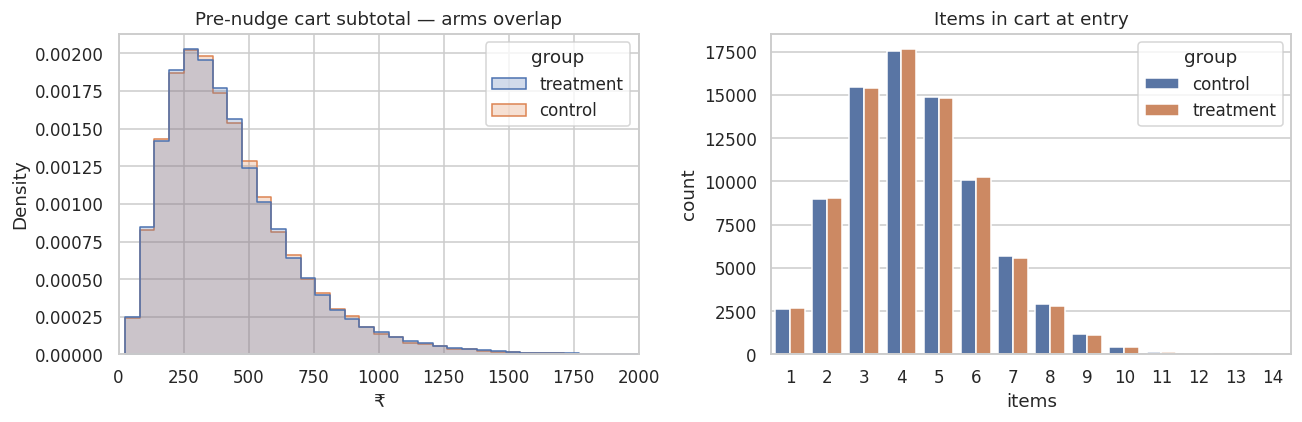

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="cart_subtotal_inr", hue="group", bins=60, element="step",
             stat="density", common_norm=False, ax=axes[0])
axes[0].set(xlim=(0, 2000), title="Pre-nudge cart subtotal — arms overlap", xlabel="₹")
sns.countplot(data=df, x="cart_items", hue="group", ax=axes[1])
axes[1].set(title="Items in cart at entry", xlabel="items")
plt.tight_layout()

## 4. The outcome: central tendency and dispersion of a binary metric

`order_placed` is 0/1, so its mean **is** the conversion rate, and there is nothing else
to estimate. That is the whole reason experiment 1 uses a z-test rather than a t-test:

* For a continuous metric you estimate the mean *and* the standard deviation, two
  unknowns from one sample — the extra uncertainty in σ̂ is what gives you the t
  distribution's fatter tails.
* For a Bernoulli variable, `Var = p(1-p)`. The variance is a **function of the mean**,
  not a free parameter. Estimate p and the variance comes with it for free.

So the sampling distribution of `p̂_t − p̂_c` is normal by the CLT with a variance you
already know, and the correct reference distribution is z.

In [10]:
outcome = df.groupby("group")["order_placed"].agg(["size", "sum", "mean"])
outcome.columns = ["sessions", "orders", "conversion_rate"]
outcome["variance_p(1-p)"] = outcome["conversion_rate"] * (1 - outcome["conversion_rate"])
outcome["std_error"] = np.sqrt(outcome["variance_p(1-p)"] / outcome["sessions"])
outcome

,sessions,orders,conversion_rate,variance_p(1-p),std_error
group,,,,,
control,79960,27491,0.3438,0.2256,0.0017
treatment,80040,25638,0.3203,0.2177,0.0016


Note what the mode, median and mean say about a binary variable: the mode is 0, the
median is 0, and the mean is 0.33. For a 0/1 outcome only the mean carries information —
the other two measures of central tendency are degenerate. Dispersion is likewise fixed
by p: the standard deviation is `sqrt(p(1-p))` ≈ 0.47, and it cannot be anything else.

In [11]:
print(df["order_placed"].agg(["mean", "median", "std", "var"]))
print(f"\nmode: {df['order_placed'].mode().iloc[0]}")
print(f"sqrt(p(1-p)) = {np.sqrt(df['order_placed'].mean() * (1 - df['order_placed'].mean())):.4f}")

mean     0.3321
median   0.0000
std      0.4710
var      0.2218
Name: order_placed, dtype: float64

mode: 0
sqrt(p(1-p)) = 0.4710


## 5. Volume and conversion over time

Two questions: did traffic behave normally for four weeks (no outage, no tracking gap),
and is the treatment effect stable or is it a novelty spike that will decay?

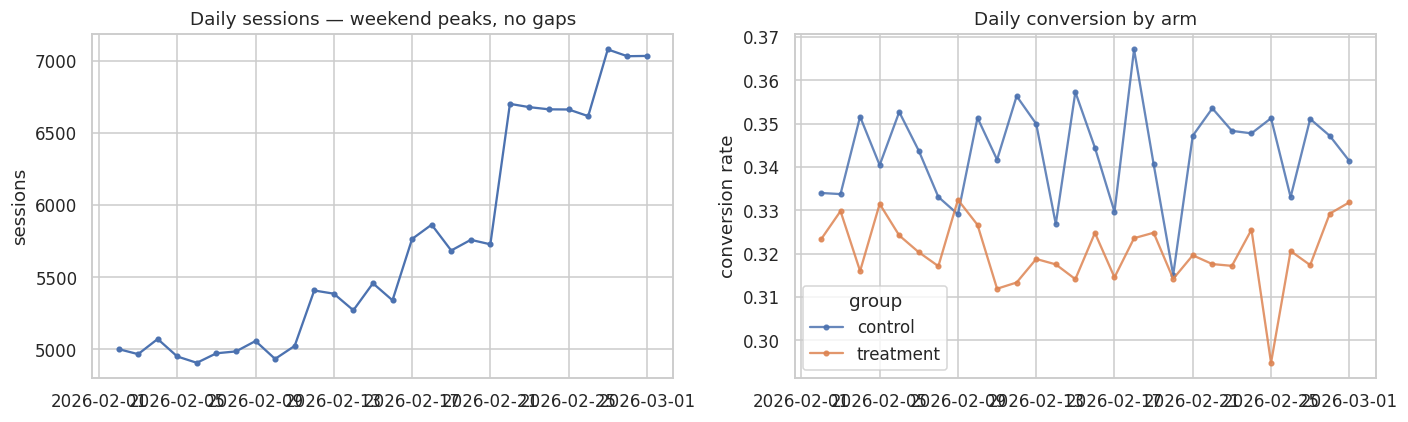

In [12]:
df["date"] = df["session_ts"].dt.date
df["hour"] = df["session_ts"].dt.hour
df["week"] = ((df["session_ts"] - df["session_ts"].min()).dt.days // 7 + 1).clip(1, 4)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df.groupby("date").size().plot(ax=axes[0], marker="o", ms=3)
axes[0].set(title="Daily sessions — weekend peaks, no gaps", ylabel="sessions", xlabel="")
daily = df.groupby(["date", "group"])["order_placed"].mean().unstack()
daily.plot(ax=axes[1], marker="o", ms=3, alpha=0.85)
axes[1].set(title="Daily conversion by arm", ylabel="conversion rate", xlabel="")
plt.tight_layout()

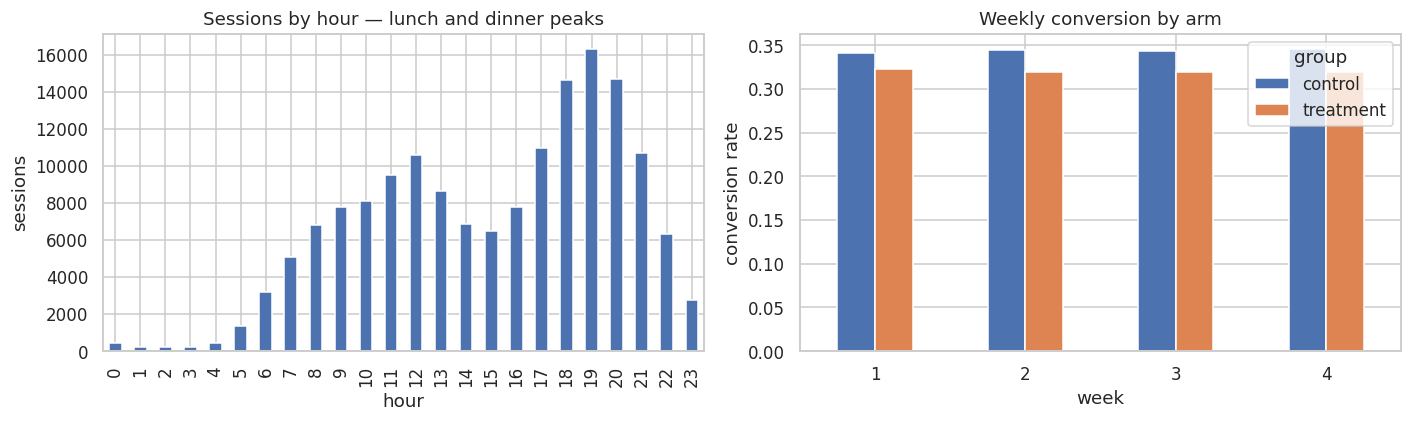

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df.groupby("hour").size().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set(title="Sessions by hour — lunch and dinner peaks", ylabel="sessions")
df.groupby(["week", "group"])["order_placed"].mean().unstack().plot(kind="bar", ax=axes[1], rot=0)
axes[1].set(title="Weekly conversion by arm", ylabel="conversion rate")
plt.tight_layout()

Traffic looks healthy: weekend-heavy days, lunch and dinner peaks, no missing days. The
treatment line sits below control on essentially every day of the experiment — the gap
is not one bad weekend.

## 6. Segments — exploratory only

The conversion gap is not uniform. Looking at it by city tier is the single most useful
cut, because tier-3 baskets sit far below the ₹499 threshold: for those users the nudge
mostly advertises a fee they were about to pay anyway.

These are descriptive numbers. Formal segment tests, with a multiple-comparison
correction, belong in notebook 03 — computing a p-value here and then "confirming" it
there would be double-dipping.

In [14]:
segment = df.pivot_table(index="city_tier", columns="group", values="order_placed",
                         aggfunc=["size", "mean"])
segment.columns = ["control_n", "treatment_n", "control_rate", "treatment_rate"]
segment["gap_pp"] = (segment["treatment_rate"] - segment["control_rate"]) * 100
segment

,control_n,treatment_n,control_rate,treatment_rate,gap_pp
city_tier,,,,,
metro,31704,32027,0.3634,0.3521,-1.1252
tier_2,28207,28004,0.3441,0.3267,-1.7360
tier_3,20049,20009,0.3124,0.2604,-5.2052


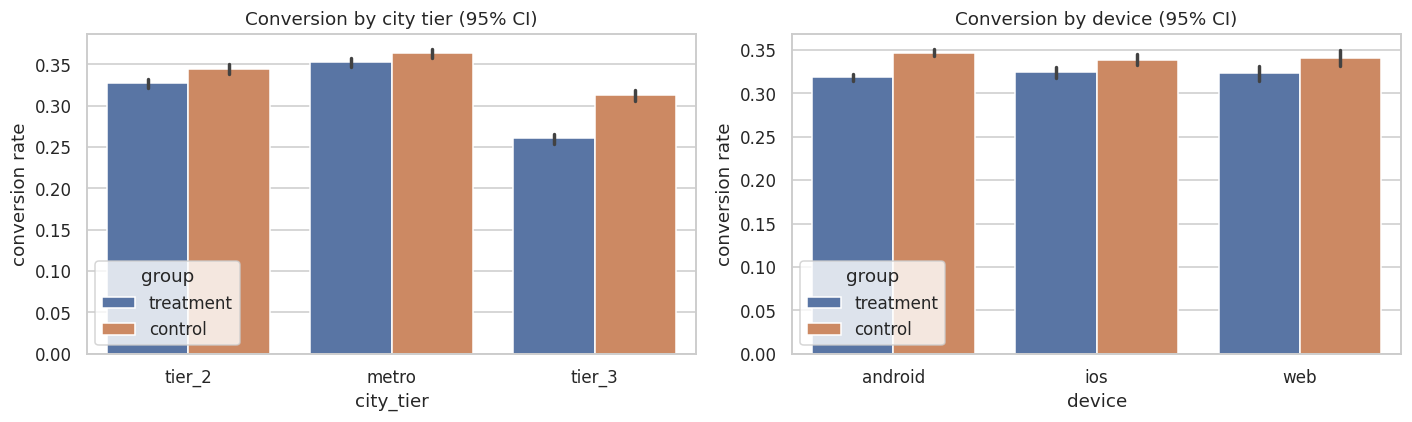

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=df, x="city_tier", y="order_placed", hue="group", errorbar=("ci", 95), ax=axes[0])
axes[0].set(title="Conversion by city tier (95% CI)", ylabel="conversion rate")
sns.barplot(data=df, x="device", y="order_placed", hue="group", errorbar=("ci", 95), ax=axes[1])
axes[1].set(title="Conversion by device (95% CI)", ylabel="conversion rate")
plt.tight_layout()

## What carries into notebook 03

| | |
| --- | --- |
| Analysis population | 160,000 de-duplicated cart sessions, one per user |
| Unit | the cart session (= the user) — independent observations |
| Primary metric | `order_placed`, binary |
| Test | pooled two-proportion **z-test**, two-sided, α = 0.05, power = 0.80 |
| Known caveat | web traffic carries a real SRM; the result must be re-checked without it |
| Segment to watch | `city_tier`, where the raw gap ranges from ~1 pp to ~5 pp |

The orders table — basket value, delivery economics, and the continuous metrics — is the
subject of notebook 02.